In [47]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings(action = 'ignore')

In [48]:
df = pd.read_csv('startup_funding (1).csv')

In [49]:
np.set_printoptions(threshold= np.inf)

In [50]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [51]:
df.columns

Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='object')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [53]:
(df.isnull().sum()/df.shape[0])*100


Sr No                 0.000000
Date dd/mm/yyyy       0.000000
Startup Name          0.000000
Industry Vertical     5.617608
SubVertical          30.749014
City  Location        5.913272
Investors Name        0.788436
InvestmentnType       0.131406
Amount in USD        31.537451
Remarks              86.235217
dtype: float64

In [54]:
def preprocessor(df):


    cat_cols = ['industry_freq', 'sub_freq', 'city_freq',
       'type_freq']
    for i in cat_cols:
      df[i] = df[i].str.strip().str.replace(r'\s+','',regex = True).str.replace(r'\\+n','',regex = True).str.replace(r'\\+x[a-z0-9]+','',regex = True).str.replace('-','').str.replace('N/A','').str.replace(r'\\*','',regex = True).str.lower()
    
    df['city_freq'] = df['city_freq'].str.strip().str.replace('uand','u/').str.replace('nw','new').str.replace('&','').str.replace('delhicambridge','delhi/cambridge').str.replace(',','/').str.replace('bengaluru','bangalore')
    
    df.dropna(thresh=4,inplace = True)
    df['industry_freq'].fillna('unknown', inplace = True)
    df['city_freq'].fillna('unknown', inplace = True)
    df['sub_freq'].fillna('unknown', inplace = True)
    
    return df

joblib.dump(preprocessor,'preprocessor.pkl')

['preprocessor.pkl']

In [55]:
def preprocess_data(df):

    df.columns = ['sr_no', 'date', 'startup_name', 'industry_vertical', 'sub_vertical',
       'city_location', 'investors_name', 'investment_type', 'amount_in_usd',
       'remarks']
    df.drop(columns=['remarks','sr_no','date','startup_name','investors_name'],inplace = True)
  

    df['amount_in_usd'] = df['amount_in_usd'].str.replace('unknown','0',case = 'False').str.replace('N/A','0',case = 'False').str.replace('+','',case = 'False').str.strip().str.replace(',','').str.replace(r'\\*x[a-z][0-9]','',regex = True).str.replace('Undisclosed','0',case = 'False').str.replace('undisclosed','0',case = 'False')
    df['amount_in_usd'] = pd.to_numeric(df['amount_in_usd'],errors = 'coerce')

    cat_cols = ['industry_vertical', 'sub_vertical', 'city_location',
       'investment_type']
    for i in cat_cols:
      df[i] = df[i].str.strip().str.replace(r'\s+','',regex = True).str.replace(r'\\+n','',regex = True).str.replace(r'\\+x[a-z0-9]+','',regex = True).str.replace('-','').str.replace('N/A','').str.replace(r'\\*','',regex = True).str.lower()
    
    df['city_location'] = df['city_location'].str.strip().str.replace('uand','u/').str.replace('nw','new').str.replace('&','').str.replace('delhicambridge','delhi/cambridge').str.replace(',','/').str.replace('bengaluru','bangalore')
    df[['city_location','city2']] = df['city_location'].str.split('/',expand = True)
    df.drop(columns = 'city2',inplace = True)
    
    df.dropna(thresh=4,inplace = True)
    df['investment_type'].fillna('unknown', inplace = True)
    df['city_location'].fillna('unknown', inplace = True)
    df['sub_vertical'].fillna('unknown', inplace = True)
    df['amount_in_usd'].fillna(0, inplace = True)

    df['amount_in_usd'] = df['amount_in_usd'].clip(
       lower=-7500000.0 ,
       upper=12500000.0
    )
    
    return df

# Preprocessing


In [56]:
preprocess_data(df)

,industry_vertical,sub_vertical,city_location,investment_type,amount_in_usd
0,etech,elearning,bangalore,privateequityround,12500000.0
1,transportation,appbasedshuttleservice,gurgaon,seriesc,8048394.0
2,ecommerce,retailerofbabyandtoddlerproducts,bangalore,seriesb,12500000.0
3,fintech,onlineinvestment,newdelhi,preseriesa,3000000.0
4,fashionandapparel,embroiledclothesforwomen,mumbai,seedround,1800000.0
...,...,...,...,...,...
2867,cloudenterprisesoftware,unknown,pune,privateequity,6000000.0
2868,startupanalyticsplatform,unknown,bangalore,privateequity,3500000.0
2870,financialmarketssoftware,unknown,bangalore,seedfunding,400000.0
2871,hiringanalyticsplatform,unknown,chennai,seedfunding,500000.0


In [57]:
freq_maps = {
    "city_freq": df["city_location"].value_counts(normalize=True),
    "industry_freq": df["industry_vertical"].value_counts(normalize=True),
    "sub_freq" : df['sub_vertical'].value_counts(normalize=True),
    "type_freq" : df['investment_type'].value_counts(normalize = True)
}




In [58]:
def encoding(df):
    freq_city = df['city_location'].value_counts(normalize=True)
    df['city_freq'] = df['city_location'].map(freq_city)

    freq_industry = df['industry_vertical'].value_counts(normalize=True)
    df['industry_freq'] = df['industry_vertical'].map(freq_industry)

    freq_sub = df['sub_vertical'].value_counts(normalize=True)
    df['sub_freq'] = df['sub_vertical'].map(freq_sub)

    freq_type = df['investment_type'].value_counts(normalize=True)
    df['type_freq'] = df['investment_type'].map(freq_type)

In [59]:
encoding(df)

In [60]:
df.columns

Index(['industry_vertical', 'sub_vertical', 'city_location', 'investment_type',
       'amount_in_usd', 'city_freq', 'industry_freq', 'sub_freq', 'type_freq'],
      dtype='object')

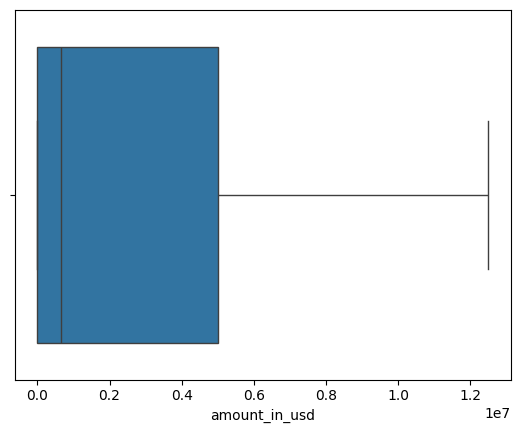

In [61]:
sns.boxplot(x = df['amount_in_usd'])
plt.show()

In [62]:
df.to_csv('data_for_model.csv')

# Classification

In [63]:
df['funded'] = (df['amount_in_usd']>0).astype('bool')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2628 entries, 0 to 2872
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   industry_vertical  2628 non-null   object 
 1   sub_vertical       2628 non-null   object 
 2   city_location      2628 non-null   object 
 3   investment_type    2628 non-null   object 
 4   amount_in_usd      2628 non-null   float64
 5   city_freq          2628 non-null   float64
 6   industry_freq      2628 non-null   float64
 7   sub_freq           2628 non-null   float64
 8   type_freq          2628 non-null   float64
 9   funded             2628 non-null   bool   
dtypes: bool(1), float64(5), object(4)
memory usage: 207.9+ KB


In [65]:
df.columns

Index(['industry_vertical', 'sub_vertical', 'city_location', 'investment_type',
       'amount_in_usd', 'city_freq', 'industry_freq', 'sub_freq', 'type_freq',
       'funded'],
      dtype='object')

In [66]:
from sklearn.model_selection import train_test_split
x = df[['industry_freq', 'sub_freq', 'type_freq', 'city_freq' ]]
y = df['funded']

x_train1,x_test1,y_train1,y_test1 = train_test_split(x,y,test_size=0.3, random_state=32,shuffle = True)



In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score


logisticreg = LogisticRegression(random_state=100,max_iter = 1000,class_weight='balanced')
logisticreg.fit(x_train1,y_train1)

y_pred1 = logisticreg.predict(x_test1)

print('Logistic Regression Classifier Performance Report')
print(classification_report(y_test1,y_pred1))

print('ROC_AUC Score',roc_auc_score(y_test1, y_pred1))




Logistic Regression Classifier Performance Report
              precision    recall  f1-score   support

       False       0.36      0.82      0.50       210
        True       0.88      0.47      0.61       579

    accuracy                           0.56       789
   macro avg       0.62      0.65      0.56       789
weighted avg       0.74      0.56      0.58       789

ROC_AUC Score 0.6459289415247964


In [68]:
rfc = RandomForestClassifier(random_state= 32,n_estimators= 100,class_weight='balanced')
rfc.fit(x_train1,y_train1)

y_pred1 = rfc.predict(x_test1)


print('Random Forest Classifier Performance Report')
print(classification_report(y_test1,y_pred1))

print('ROC_AUC Score',roc_auc_score(y_test1, y_pred1))


Random Forest Classifier Performance Report
              precision    recall  f1-score   support

       False       0.44      0.66      0.53       210
        True       0.85      0.69      0.76       579

    accuracy                           0.68       789
   macro avg       0.64      0.68      0.64       789
weighted avg       0.74      0.68      0.70       789

ROC_AUC Score 0.675511966444609


In [69]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        )
gbc.fit(x_train1,y_train1)
y_pred1 = gbc.predict(x_test1)

print('Gradient Boosting Classifier Performance Report')
print(classification_report(y_test1,y_pred1))
print('ROC_AUC Score',roc_auc_score(y_test1, y_pred1))


Gradient Boosting Classifier Performance Report
              precision    recall  f1-score   support

       False       0.50      0.33      0.40       210
        True       0.78      0.88      0.83       579

    accuracy                           0.73       789
   macro avg       0.64      0.60      0.61       789
weighted avg       0.71      0.73      0.71       789

ROC_AUC Score 0.6038366641993586


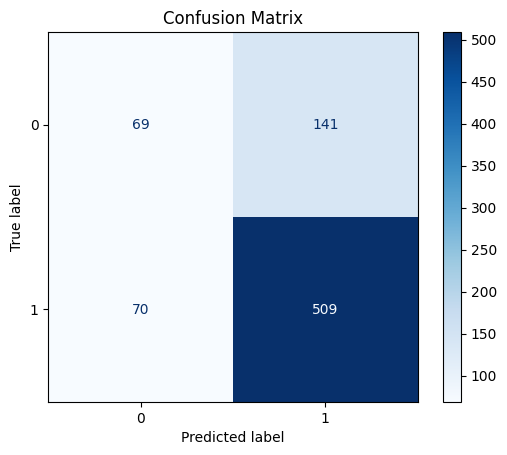

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test1, y_pred1)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# Regression

In [71]:
df.columns

Index(['industry_vertical', 'sub_vertical', 'city_location', 'investment_type',
       'amount_in_usd', 'city_freq', 'industry_freq', 'sub_freq', 'type_freq',
       'funded'],
      dtype='object')

In [72]:
df_reg = df[df['amount_in_usd']>0]
df_reg['amount_in_usd'].value_counts()

amount_in_usd
12500000.0    362
1000000.0     158
500000.0      103
2000000.0      66
3000000.0      61
             ... 
280000.0        1
437000.0        1
1790000.0       1
6250000.0       1
6800000.0       1
Name: count, Length: 317, dtype: int64

In [73]:

x = df_reg[['industry_freq', 'sub_freq', 'type_freq', 'city_freq' ]]
y = df_reg['amount_in_usd']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=32,shuffle = True)



In [74]:

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)


In [75]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train,y_train_log)

y_pred_log = lr.predict(x_test)
y_pred = np.expm1(y_pred_log)

from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score
print('Metrics for Multiple Linear Regression....\nMean Absolute Error: ',mean_absolute_error(y_test,y_pred),'\nRoot Mean Squared Error:',root_mean_squared_error(y_test,y_pred),'\nR2 Score:',r2_score(y_test,y_pred))

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_log  = mean_absolute_error(y_test_log, y_pred_log)
rmse_log = root_mean_squared_error(y_test_log, y_pred_log)
r2_log   = r2_score(y_test_log, y_pred_log)

print("Log-space MAE:", mae_log)
print("Log-space RMSE:", rmse_log)
print("Log-space R2:", r2_log)



Metrics for Multiple Linear Regression....
Mean Absolute Error:  3529298.4292614223 
Root Mean Squared Error: 5169887.458956005 
R2 Score: -0.22448043480541235
Log-space MAE: 1.3814576529054834
Log-space RMSE: 1.6145859787988068
Log-space R2: 0.046205091485237215


In [76]:
from sklearn.ensemble import RandomForestRegressor

rr = RandomForestRegressor(n_estimators=50)

rr.fit(x_train, y_train_log)

y_pred_log = rr.predict(x_test)
y_pred = np.expm1(y_pred_log)
print('Metrics for Random Forest Regression....\nMean Absolute Error: ',mean_absolute_error(y_test,y_pred),'\nRoot Mean Squared Error:',root_mean_squared_error(y_test,y_pred),'\nR2 Score:',r2_score(y_test,y_pred))

ae_log  = mean_absolute_error(y_test_log, y_pred_log)
rmse_log = root_mean_squared_error(y_test_log, y_pred_log)
r2_log   = r2_score(y_test_log, y_pred_log)

print("Log-space MAE:", mae_log)
print("Log-space RMSE:", rmse_log)
print("Log-space R2:", r2_log)


Metrics for Random Forest Regression....
Mean Absolute Error:  2713366.382773644 
Root Mean Squared Error: 4034622.3890791773 
R2 Score: 0.25424622550829523
Log-space MAE: 1.3814576529054834
Log-space RMSE: 1.126720308718769
Log-space R2: 0.5355222752178515


In [77]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

gbr.fit(x_train, y_train_log)

y_pred_log = gbr.predict(x_test)
y_pred = np.expm1(y_pred_log)
print('Metrics for gradient boosting model....\nMean Absolute Error: ',mean_absolute_error(y_test,y_pred),'\nRoot Mean Squared Error:',root_mean_squared_error(y_test,y_pred),'\nR2 Score:',r2_score(y_test,y_pred))

mae_log  = mean_absolute_error(y_test_log, y_pred_log)
rmse_log = root_mean_squared_error(y_test_log, y_pred_log)
r2_log   = r2_score(y_test_log, y_pred_log)

print("Log-space MAE:", mae_log)
print("Log-space RMSE:", rmse_log)
print("Log-space R2:", r2_log)



Metrics for gradient boosting model....
Mean Absolute Error:  2532980.619814248 
Root Mean Squared Error: 3836655.11645581 
R2 Score: 0.32563473188635994
Log-space MAE: 0.8328309536975815
Log-space RMSE: 1.0462211843186429
Log-space R2: 0.5995210759514915


## Actual vs Predicted Values Comparision(Gradient Boosting) 


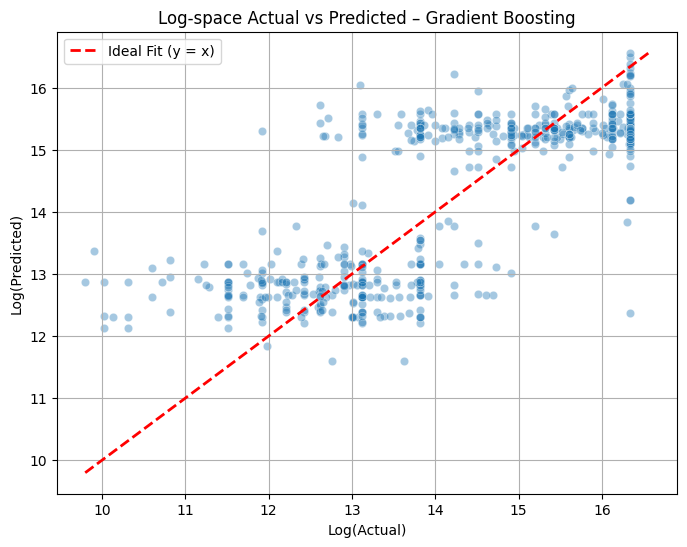

In [78]:
import numpy as np

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=np.log1p(y_test),
    y=np.log1p(y_pred),
    alpha=0.4
)

limits = [
    min(np.log1p(y_test).min(), np.log1p(y_pred).min()),
    max(np.log1p(y_test).max(), np.log1p(y_pred).max())
]

plt.plot(limits, limits, 'r--', linewidth=2, label='Ideal Fit (y = x)')
plt.xlabel('Log(Actual)')
plt.ylabel('Log(Predicted)')
plt.title('Log-space Actual vs Predicted – Gradient Boosting')
plt.legend()
plt.grid(True)
plt.show()


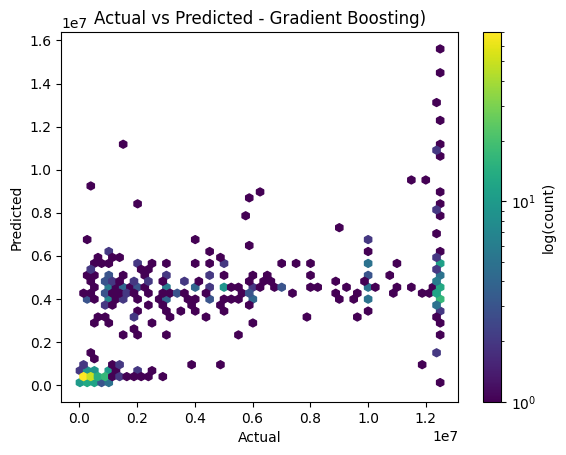

In [79]:
plt.hexbin(y_test, y_pred, gridsize=50, bins='log')
plt.plot(limits, limits, 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted - Gradient Boosting)')
plt.colorbar(label='log(count)')
plt.show()


# Predicting Real Data from User

In [ ]:
preprocessor = joblib.load('preprocessor.pkl')

def apply_frequency_encoding(df, freq_maps):
    df = df.copy()
    for col, fmap in freq_maps.items():
        df[col] = df[col].map(fmap)
        df[col] = df[col].fillna(0)  # unseen categories
    return df


def get_user_input():
    user_data = {
        "industry_freq": input("Enter Industry Vertical: "),
        "sub_freq": input("Enter Industry Sub Vertical: "),
        "type_freq": input("Enter Type of Funding: "),
        "city_freq": input("Enter Location(City) of Startup: ")
    }
    return user_data

def prediction(user_data):
    input_df = pd.DataFrame([user_data])
    input_df = preprocessor(input_df)

    input_df = apply_frequency_encoding(input_df, freq_maps)

    print(user_data)

    pred = gbc.predict(input_df)
    funded = 'Yes' if pred else 'No'
    print(funded)


    if pred:
        amount = np.expm1(gbr.predict(input_df))

        print(f"The predicted amount for the startup is {amount[0].round()} USD.")
    else:
        print("The predicted amount for the startup is 0.0 USD.")

    


In [81]:
user_data = get_user_input()
prediction(user_data)


{'industry_freq': 'E Tech', 'sub_freq': 'E Learning', 'type_freq': 'Series A', 'city_freq': 'Bangalore'}
Yes
The predicted amount for the startup is 6240007.0 USD.
